## Models Training

In [47]:
# import library
import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import FunctionTransformer, PowerTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [48]:
## Load feature engineered dataset into a dataframe
df = pd.read_csv("../data/processed/feature_engineered_flipcart_laptop_data.csv")

## Top five observations
df.head()

,Discount price,Stars,Rating,Reviews,discount_pct(%),brand,ram_gb,storage_gb,storage_type,processor_tier,is_gaming,processor_brand,processor_generation,premium_brand
0,54990.0,3.9,7.0,1.0,38.89,MSI,16.0,512.0,SSD,Mid,0,Intel,12,1
1,67990.0,0.0,0.0,0.0,19.05,MSI,8.0,1024.0,SSD,High,0,Intel,12,1
2,35660.0,4.2,1805.0,143.0,27.58,DELL,8.0,512.0,SSD,Entry,0,Intel,12,0
3,26990.0,4.2,6977.0,596.0,38.66,Acer,8.0,512.0,SSD,Entry,0,Intel,11,0
4,27989.0,4.2,1263.0,113.0,52.88,Lenovo,8.0,512.0,SSD,Entry,0,AMD,0,0


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 923 entries, 0 to 922
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Discount price        923 non-null    float64
 1   Stars                 923 non-null    float64
 2   Rating                923 non-null    float64
 3   Reviews               923 non-null    float64
 4   discount_pct(%)       923 non-null    float64
 5   brand                 923 non-null    str    
 6   ram_gb                923 non-null    float64
 7   storage_gb            923 non-null    float64
 8   storage_type          923 non-null    str    
 9   processor_tier        923 non-null    str    
 10  is_gaming             923 non-null    int64  
 11  processor_brand       923 non-null    str    
 12  processor_generation  923 non-null    int64  
 13  premium_brand         923 non-null    int64  
dtypes: float64(7), int64(3), str(4)
memory usage: 101.1 KB


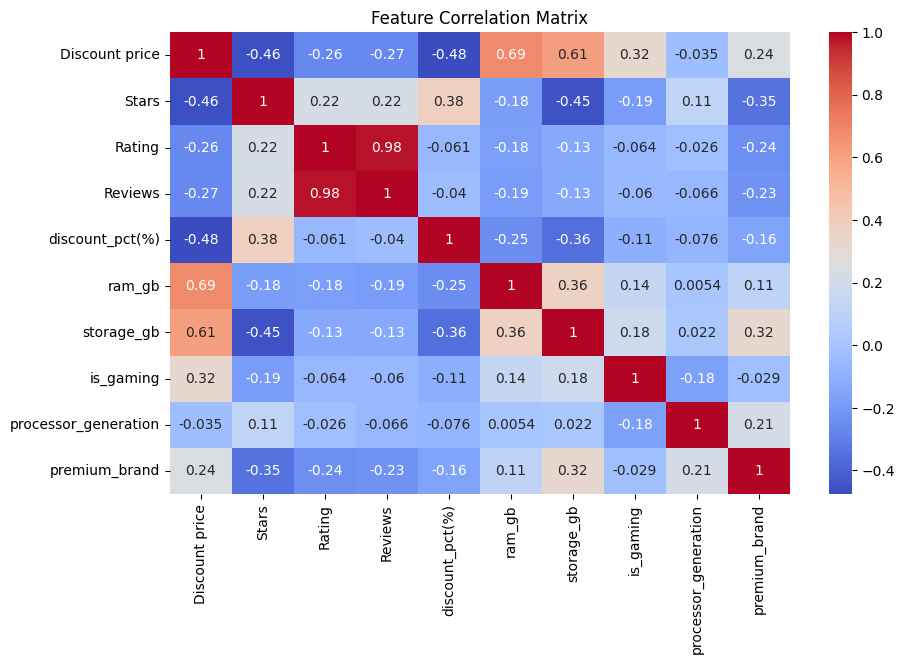

In [50]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Matrix")
plt.show()

### Create Features and Target Variable

In [51]:
# Features
X = df.drop(columns=['Discount price'])
# Target
y = df["Discount price"]

X.head()

,Stars,Rating,Reviews,discount_pct(%),brand,ram_gb,storage_gb,storage_type,processor_tier,is_gaming,processor_brand,processor_generation,premium_brand
0,3.9,7.0,1.0,38.89,MSI,16.0,512.0,SSD,Mid,0,Intel,12,1
1,0.0,0.0,0.0,19.05,MSI,8.0,1024.0,SSD,High,0,Intel,12,1
2,4.2,1805.0,143.0,27.58,DELL,8.0,512.0,SSD,Entry,0,Intel,12,0
3,4.2,6977.0,596.0,38.66,Acer,8.0,512.0,SSD,Entry,0,Intel,11,0
4,4.2,1263.0,113.0,52.88,Lenovo,8.0,512.0,SSD,Entry,0,AMD,0,0


In [52]:
X.shape

(923, 13)

In [53]:
y.head()

0    54990.0
1    67990.0
2    35660.0
3    26990.0
4    27989.0
Name: Discount price, dtype: float64

In [54]:
## Apply log transformation on y as it too much right skewed
def log_transformer(series):
    transformed_series = np.log1p(series)
    return transformed_series

def reversed_log_transformer(log_series):
    reversed_log_series = np.expm1(log_series)
    return reversed_log_series

log_y = log_transformer(y)
log_y

0      10.914925
1      11.127131
2      10.481813
3      10.203259
4      10.239603
         ...    
918    11.258046
919    11.289669
920    10.403990
921    10.885397
922    10.571086
Name: Discount price, Length: 923, dtype: float64

### Splitting into training and testing set

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_log, y_test_log = train_test_split(X, log_y, test_size=0.2, random_state=42)

print("Shape of X_train", X_train.shape)
print("Shape of X_test", X_test.shape)
print("Shape of y_train", y_train_log.shape)
print("Shape of y_test", y_test_log.shape)

Shape of X_train (738, 13)
Shape of X_test (185, 13)
Shape of y_train (738,)
Shape of y_test (185,)


In [56]:
X_train.head()

,Stars,Rating,Reviews,discount_pct(%),brand,ram_gb,storage_gb,storage_type,processor_tier,is_gaming,processor_brand,processor_generation,premium_brand
97,3.7,602.0,76.0,52.51,CHUWI,8.0,256.0,SSD,Entry,0,Intel,11,0
227,3.8,69.0,8.0,36.39,Acer,8.0,512.0,SSD,Entry,0,Intel,0,0
692,4.5,13.0,3.0,30.27,ASUS,16.0,512.0,SSD,Other,1,AMD,0,0
587,5.0,3.0,0.0,31.26,Thomson,8.0,256.0,SSD,Entry,0,Intel,12,0
883,3.8,611.0,53.0,30.08,HP,8.0,256.0,SSD,Entry,0,Intel,0,0


In [57]:
## Initialize the PowerTransformer
yeo_trf = PowerTransformer(method='yeo-johnson')

## Instantiate of log transformer
log_trf = FunctionTransformer(np.log1p)

## Pipeline for sequential execution
numeric_pipeline = Pipeline([
    ("log_transform", log_trf),
    ("scaler", StandardScaler())
])

yeo_pipeline = Pipeline([
    ("yeo_transform", yeo_trf),
    ("scaler", StandardScaler())
])

In [58]:
## Create Column Transformer
transformer = ColumnTransformer(
    transformers=[
        ("numeric_pipeline", numeric_pipeline, ["Rating", "Reviews", "ram_gb", "storage_gb", "discount_pct(%)"]),
        ("yeo_pipeline", yeo_pipeline, ["Stars"]),

        # 1. TARGET ENCODING FOR BRAND (Keeps it as 1 column)
        ("target_enc", TargetEncoder(smooth="auto", cv=5, target_type='continuous'), ["brand"]),

        ("OneHotEncoding", OneHotEncoder(
            drop='first',
            min_frequency=6,          # Categories appearing < 6 times become 'Other'
            handle_unknown='infrequent_if_exist', 
            sparse_output=False
            ), ["storage_type", "processor_brand"]
        ),

        ("OrdinalEncoding",OrdinalEncoder(categories=[["Entry", "Mid", "High", "Ultra", "Other"]]),["processor_tier"])
    ],
    
    remainder='passthrough'
)

In [59]:
## Fit and Transform the Training Set
X_train_trf = transformer.fit_transform(X_train, y_train_log)
X_train_trf

array([[ 0.73265806,  0.81248057, -0.742441  , ...,  0.        ,
        11.        ,  0.        ],
       [-0.0133741 , -0.15594907, -0.742441  , ...,  0.        ,
         0.        ,  0.        ],
       [-0.57094826, -0.52180012,  0.9923504 , ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [ 0.74507256,  0.98553372, -0.742441  , ...,  0.        ,
        11.        ,  0.        ],
       [ 0.72097263,  0.69235381, -0.742441  , ...,  0.        ,
        11.        ,  0.        ],
       [ 1.09538068,  1.10112679,  0.9923504 , ...,  0.        ,
        12.        ,  0.        ]], shape=(738, 14))

In [60]:
X_train_trf.shape

(738, 14)

In [61]:
## Transform only Testing set
X_test_trf = transformer.transform(X_test)
X_test_trf

array([[-1.48522409, -1.14722663,  0.9923504 , ...,  0.        ,
        12.        ,  0.        ],
       [ 0.97077548,  0.97747726, -0.742441  , ...,  0.        ,
        11.        ,  0.        ],
       [-0.76482173, -0.83451337,  0.9923504 , ...,  0.        ,
        12.        ,  1.        ],
       ...,
       [ 1.30019916,  1.29019051, -0.742441  , ...,  0.        ,
        12.        ,  0.        ],
       [-1.48522409, -1.14722663,  0.9923504 , ...,  0.        ,
        12.        ,  0.        ],
       [-1.00495585, -0.83451337,  0.9923504 , ...,  0.        ,
        12.        ,  0.        ]], shape=(185, 14))

### Regularized Model Training

This section replaces the earlier high-variance model blocks with a smaller set of regularized candidates.
The goal is to improve generalization by:

- using a single target strategy for every model
- keeping tree depth shallow
- increasing minimum leaf sizes
- using cross-validation and explicitly tracking the train/test gap


In [62]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, RandomizedSearchCV, cross_val_score


y_train = y.loc[X_train.index].copy()
y_test = y.loc[X_test.index].copy()

cv = KFold(n_splits=5, shuffle=True, random_state=42)


def build_pipeline(regressor):
    return Pipeline([
        ("preprocessor", transformer),
        (
            "model",
            TransformedTargetRegressor(
                regressor=regressor,
                func=np.log1p,
                inverse_func=np.expm1,
            ),
        ),
    ])


def evaluate_pipeline(name, pipeline):
    pipeline.fit(X_train, y_train)

    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="r2",
        n_jobs=1,
    )

    metrics = {
        "Model": name,
        "Train R2": r2_score(y_train, y_train_pred),
        "Test R2": r2_score(y_test, y_test_pred),
        "CV Mean R2": cv_scores.mean(),
        "CV Std R2": cv_scores.std(),
        "Train-Test Gap": r2_score(y_train, y_train_pred) - r2_score(y_test, y_test_pred),
        "Train MAE": mean_absolute_error(y_train, y_train_pred),
        "Test MAE": mean_absolute_error(y_test, y_test_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
    }

    return metrics, y_train_pred, y_test_pred


#### Tune Stable Candidate Models

Only regularized candidates are compared below. Every search uses `n_jobs=1` so the notebook runs cleanly in restricted environments.

In [63]:
elastic_net_pipeline = build_pipeline(
    ElasticNet(max_iter=20000, random_state=42)
)

elastic_net_grid = {
    "model__regressor__alpha": [0.01, 0.05, 0.1, 0.5, 1.0],
    "model__regressor__l1_ratio": [0.2, 0.4, 0.6, 0.8],
}

elastic_net_search = GridSearchCV(
    estimator=elastic_net_pipeline,
    param_grid=elastic_net_grid,
    cv=cv,
    scoring="r2",
    n_jobs=1,
    return_train_score=True,
)

elastic_net_search.fit(X_train, y_train)

print("ElasticNet best params:", elastic_net_search.best_params_)
print("ElasticNet CV R2:", round(elastic_net_search.best_score_, 4))


ElasticNet best params: {'model__regressor__alpha': 0.01, 'model__regressor__l1_ratio': 0.2}
ElasticNet CV R2: 0.7678


In [64]:
rf_pipeline = build_pipeline(
    RandomForestRegressor(
        random_state=42,
        bootstrap=True,
    )
)

rf_param_grid = {
    "model__regressor__n_estimators": [200, 300],
    "model__regressor__max_depth": [3, 4, 5],
    "model__regressor__min_samples_split": [10, 20, 30],
    "model__regressor__min_samples_leaf": [8, 12, 16],
    "model__regressor__max_features": [0.4, 0.6, "sqrt"],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=10,
    cv=cv,
    scoring="r2",
    n_jobs=1,
    random_state=42,
    return_train_score=True,
)

rf_search.fit(X_train, y_train)

print("Random Forest best params:", rf_search.best_params_)
print("Random Forest CV R2:", round(rf_search.best_score_, 4))


Random Forest best params: {'model__regressor__n_estimators': 300, 'model__regressor__min_samples_split': 10, 'model__regressor__min_samples_leaf': 8, 'model__regressor__max_features': 0.4, 'model__regressor__max_depth': 5}
Random Forest CV R2: 0.7785


In [65]:
gb_pipeline = build_pipeline(
    GradientBoostingRegressor(random_state=42)
)

gb_param_grid = {
    "model__regressor__n_estimators": [100, 150, 200],
    "model__regressor__learning_rate": [0.03, 0.05],
    "model__regressor__max_depth": [2, 3],
    "model__regressor__min_samples_split": [10, 20],
    "model__regressor__min_samples_leaf": [6, 10],
    "model__regressor__subsample": [0.7, 0.8],
    "model__regressor__max_features": [0.5, 0.7],
}

gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=gb_param_grid,
    n_iter=10,
    cv=cv,
    scoring="r2",
    n_jobs=1,
    random_state=42,
    return_train_score=True,
)

gb_search.fit(X_train, y_train)

print("Gradient Boosting best params:", gb_search.best_params_)
print("Gradient Boosting CV R2:", round(gb_search.best_score_, 4))


Gradient Boosting best params: {'model__regressor__subsample': 0.8, 'model__regressor__n_estimators': 150, 'model__regressor__min_samples_split': 20, 'model__regressor__min_samples_leaf': 6, 'model__regressor__max_features': 0.7, 'model__regressor__max_depth': 3, 'model__regressor__learning_rate': 0.05}
Gradient Boosting CV R2: 0.8431


#### Compare Models and Select the Most Stable One

In [66]:
candidate_models = {
    "ElasticNet": elastic_net_search.best_estimator_,
    "Random Forest": rf_search.best_estimator_,
    "Gradient Boosting": gb_search.best_estimator_,
}

evaluation_rows = []
predictions = {}

for model_name, model_pipeline in candidate_models.items():
    model_metrics, train_pred, test_pred = evaluate_pipeline(model_name, model_pipeline)
    evaluation_rows.append(model_metrics)
    predictions[model_name] = {
        "train": train_pred,
        "test": test_pred,
    }

results_df = pd.DataFrame(evaluation_rows).sort_values(
    by=["Test R2", "Train-Test Gap"],
    ascending=[False, True],
)

results_df.round(4)


,Model,Train R2,Test R2,CV Mean R2,CV Std R2,Train-Test Gap,Train MAE,Test MAE,Train RMSE,Test RMSE
0,ElasticNet,0.7970,0.7791,0.7690,0.0431,0.0179,7809.5148,9591.2645,12507.6690,19813.6471
2,Gradient Boosting,0.9092,0.7213,0.8414,0.0291,0.1879,4526.9180,6299.7696,8363.9241,22251.2338
1,Random Forest,0.8138,0.5751,0.7786,0.0413,0.2387,6405.2949,9281.8915,11979.2494,27476.7185


In [67]:
stable_results = results_df[
    (results_df["Train-Test Gap"] <= 0.08)
    & (results_df["CV Mean R2"] >= results_df["Test R2"] - 0.05)
].sort_values(
    by=["Test R2", "Train-Test Gap"],
    ascending=[False, True],
)

if stable_results.empty:
    stable_results = results_df.sort_values(
        by=["Train-Test Gap", "CV Std R2", "Test R2"],
        ascending=[True, True, False],
    ).head(1)

selected_model_name = stable_results.iloc[0]["Model"]
final_pipeline = candidate_models[selected_model_name]

print("Selected model:", selected_model_name)
print(stable_results.round(4))


Selected model: ElasticNet
        Model  Train R2  Test R2  CV Mean R2  CV Std R2  Train-Test Gap  \
0  ElasticNet     0.797   0.7791       0.769     0.0431          0.0179   

   Train MAE   Test MAE  Train RMSE   Test RMSE  
0  7809.5148  9591.2645   12507.669  19813.6471  


## Final Model

The final model is selected only after balancing predictive power with stability on unseen data.

In [68]:
final_pipeline.fit(X_train, y_train)

y_train_pred = final_pipeline.predict(X_train)
y_test_pred = final_pipeline.predict(X_test)

final_metrics_df = pd.DataFrame(
    {
        "Metric": ["R2 Score", "Mean Absolute Error", "Root Mean Squared Error"],
        "Train Set": [
            r2_score(y_train, y_train_pred),
            mean_absolute_error(y_train, y_train_pred),
            np.sqrt(mean_squared_error(y_train, y_train_pred)),
        ],
        "Test Set": [
            r2_score(y_test, y_test_pred),
            mean_absolute_error(y_test, y_test_pred),
            np.sqrt(mean_squared_error(y_test, y_test_pred)),
        ],
    }
)

print("Final model:", selected_model_name)
final_metrics_df.round(4)


Final model: ElasticNet


,Metric,Train Set,Test Set
0,R2 Score,0.7955,0.7754
1,Mean Absolute Error,7809.0496,9611.4270
2,Root Mean Squared Error,12554.1974,19975.3887


#### Feature Importance / Coefficient Strength

In [69]:
numeric_features = ["Rating", "Reviews", "ram_gb", "storage_gb", "discount_pct(%)"]
yeo_features = ["Stars"]
target_features = ["brand"]
ordinal_features = ["processor_tier"]
passthrough_features = ["processor_generation", "is_gaming", "premium_brand"]

fitted_preprocessor = final_pipeline.named_steps["preprocessor"]
ohe_features = fitted_preprocessor.named_transformers_["OneHotEncoding"].get_feature_names_out(
    ["storage_type", "processor_brand"]
)

feature_names = (
    numeric_features
    + yeo_features
    + target_features
    + list(ohe_features)
    + ordinal_features
    + passthrough_features
)

final_regressor = final_pipeline.named_steps["model"].regressor_

if hasattr(final_regressor, "feature_importances_"):
    importance_values = final_regressor.feature_importances_
    importance_df = pd.DataFrame(
        {"Feature": feature_names, "Importance": importance_values}
    ).sort_values(by="Importance", ascending=False)
else:
    importance_values = np.abs(final_regressor.coef_)
    importance_df = pd.DataFrame(
        {"Feature": feature_names, "Importance": importance_values}
    ).sort_values(by="Importance", ascending=False)

importance_df.head(15)


,Feature,Importance
10,processor_tier,0.149423
7,storage_type_HDD,0.145494
2,ram_gb,0.144956
11,processor_generation,0.142534
4,discount_pct(%),0.106767
9,processor_brand_Intel,0.088525
13,premium_brand,0.064610
3,storage_gb,0.062279
8,storage_type_SSD,0.048304
1,Reviews,0.031923


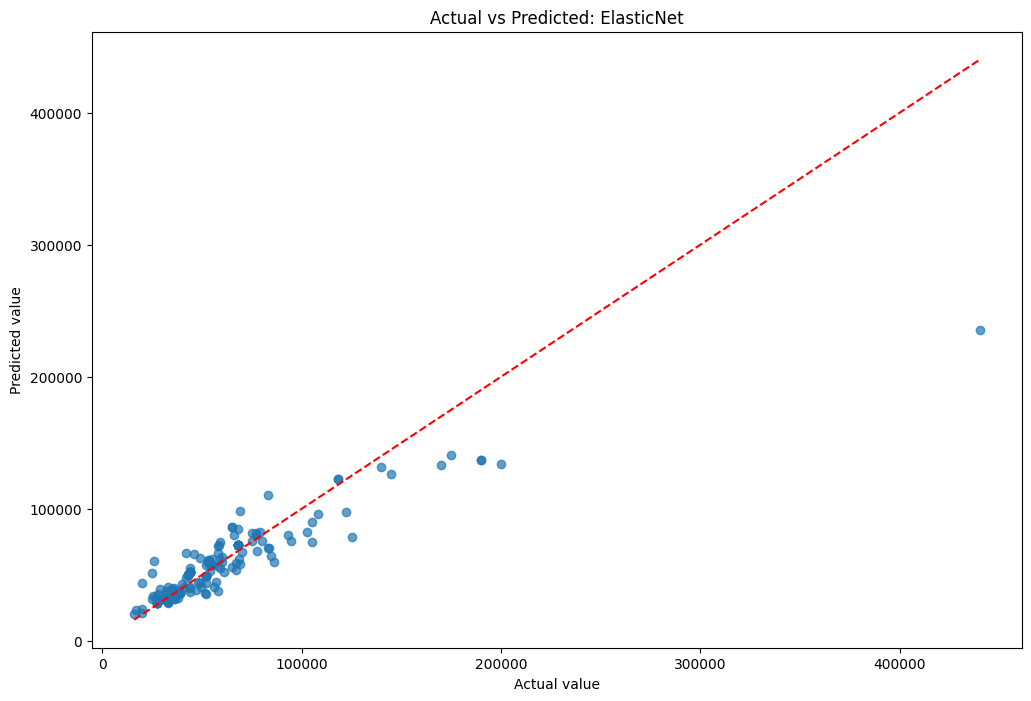

In [70]:
plt.figure(figsize=(12, 8))
plt.scatter(y_test, y_test_pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
)
plt.xlabel("Actual value")
plt.ylabel("Predicted value")
plt.title(f"Actual vs Predicted: {selected_model_name}")
plt.show()


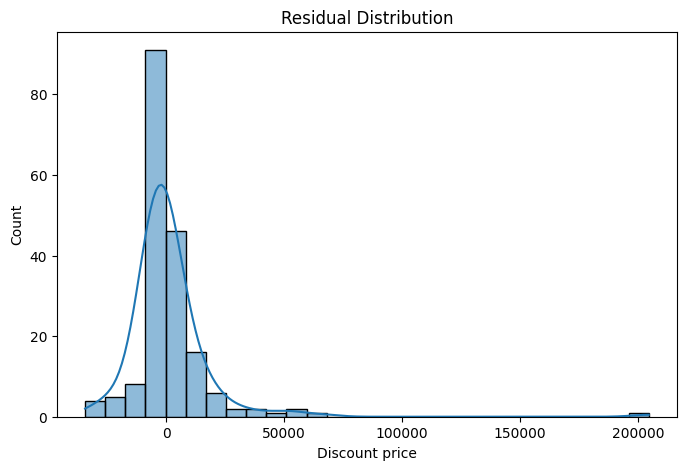

In [71]:
residuals = y_test - y_test_pred

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()


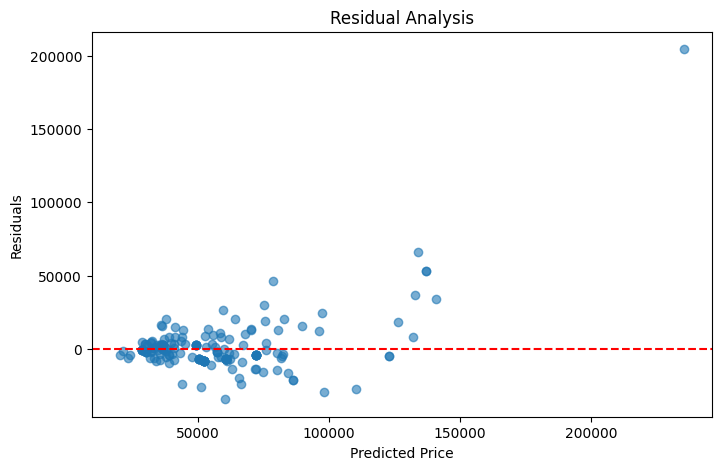

In [72]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Analysis")
plt.show()
